# Latent SOH Forecasting With Causal History Features

This notebook extends the causal `latent_soh` forecasting test into the `soh_forecast` area.

Goal:

- keep `next_latent_soh_causal_pct` as the denoised next-step target
- add strictly causal transition features
- compare whether causal latent state plus history features helps forecasting

Compared models:

- `naive_zero_delta`
- `ridge_raw_only`
- `ridge_raw_plus_latent`
- `ridge_raw_plus_latent_plus_history`
- `gbdt_raw_plus_latent_plus_history`


## Setup

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "ml_workspace").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate repo root")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

PLANE_ID = "166"
TRAIN_FRAC = 0.70
VALID_FRAC = 0.15

LATENT_OUTPUT_DIR = REPO_ROOT / "ml_workspace" / "latent_soh" / "output" / f"plane_{PLANE_ID}"
RESULT_DIR = REPO_ROOT / "ml_workspace" / "soh_forecast" / "output" / f"latent_history_plane_{PLANE_ID}"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Latent output dir:", LATENT_OUTPUT_DIR)
print("Result dir:", RESULT_DIR)


Repo root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane
Latent output dir: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/latent_soh/output/plane_166
Result dir: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/output/latent_history_plane_166


## Load latent SOH event table

In [2]:
latent_df = pd.read_csv(LATENT_OUTPUT_DIR / "latent_soh_event_table.csv", parse_dates=["event_datetime"])
summary = json.loads((LATENT_OUTPUT_DIR / "diagnostics" / "smoother_summary.json").read_text())

latent_df["plane_id"] = latent_df["plane_id"].astype(str)
latent_df["battery_id"] = pd.to_numeric(latent_df["battery_id"], errors="coerce")
latent_df["battery_id_str"] = latent_df["battery_id"].astype("Int64").astype(str)

print("Latent rows:", len(latent_df))
display(pd.DataFrame([summary]))
display(
    latent_df.groupby("battery_id", as_index=False).agg(
        n_events=("flight_id", "count"),
        observed_soh_min=("observed_soh_pct", "min"),
        observed_soh_max=("observed_soh_pct", "max"),
        latent_filter_min=("latent_soh_filter_pct", "min"),
        latent_filter_max=("latent_soh_filter_pct", "max"),
        latent_smooth_min=("latent_soh_filter_pct", "min"),
        latent_smooth_max=("latent_soh_filter_pct", "max"),
    ).round(3)
)


Latent rows: 1106


,plane_id,rt_profile,battery_ids_processed,n_events_total,n_events_per_battery,n_events_dropped_missing_observed_soh,sigma_base_pct_per_battery,q_day_sigma_pct,raw_total_variation_per_battery,smoothed_total_variation_per_battery,raw_max_upward_jump_pct_per_battery,smoothed_max_upward_jump_pct_per_battery,fraction_events_with_condition_multiplier_gt_3,notes
0,166,balanced,"[1, 2]",1106,"{'1': 553, '2': 553}",0,"{'1': 0.55, '2': 0.55}",0.05,"{'1': 484.0, '2': 469.0}","{'1': 51.14722851352783, '2': 49.6942665930803}","{'1': 29.0, '2': 25.0}","{'1': 1.0244025838651254, '2': 1.0229620160775...","{'1': 0.2766726943942134, '2': 0.2567811934900...",FilterPy latent SOH is the canonical output. P...


,battery_id,n_events,observed_soh_min,observed_soh_max,latent_filter_min,latent_filter_max,latent_smooth_min,latent_smooth_max
0,1,553,40.0,100.0,52.819,99.976,52.819,96.545
1,2,553,42.0,100.0,55.932,99.977,55.932,96.847


## Build next-step target and strictly causal history features

In [3]:
def add_history_features(df: pd.DataFrame) -> pd.DataFrame:
    out_frames = []
    for (_, battery_id), group in df.groupby(["plane_id", "battery_id"], sort=False):
        g = group.sort_values(["event_datetime", "flight_id"]).copy()

        numeric_cols = [
            "observed_soh_pct",
            "latent_soh_filter_pct",
            "_filterpy_pred_state_pct",
            "_filterpy_pred_var_pct2",
            "measurement_sigma_pct",
            "condition_multiplier",
            "current_abs_mean_a",
            "p95_abs_current_a",
            "avg_cell_temp_mean_c",
            "avg_cell_temp_span_c",
            "soc_mean_pct",
            "soc_span_pct",
            "event_duration_s",
            "delta_days",
        ]
        for col in numeric_cols:
            if col in g.columns:
                g[col] = pd.to_numeric(g[col], errors="coerce")

        g["prev_observed_soh_pct"] = g["observed_soh_pct"].shift(1)
        g["prev_latent_filter_pct"] = g["latent_soh_filter_pct"].shift(1)
        g["prev2_latent_filter_pct"] = g["latent_soh_filter_pct"].shift(2)
        g["prev_delta_days"] = g["delta_days"].shift(1)
        g["time_since_prev_event_days"] = (
            g["event_datetime"].diff().dt.total_seconds().div(86400.0)
        )

        g["latent_filter_delta_1"] = g["latent_soh_filter_pct"] - g["prev_latent_filter_pct"]
        g["latent_filter_delta_2"] = g["prev_latent_filter_pct"] - g["prev2_latent_filter_pct"]
        g["observed_soh_delta_1"] = g["observed_soh_pct"] - g["prev_observed_soh_pct"]
        g["latent_filter_slope_pct_per_day_1"] = g["latent_filter_delta_1"] / g["time_since_prev_event_days"].clip(lower=1e-3)

        g["rolling_latent_filter_mean_3"] = g["latent_soh_filter_pct"].shift(1).rolling(3, min_periods=1).mean()
        g["rolling_latent_filter_std_3"] = g["latent_soh_filter_pct"].shift(1).rolling(3, min_periods=1).std()
        g["rolling_latent_filter_delta_mean_5"] = g["latent_filter_delta_1"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_latent_filter_delta_std_5"] = g["latent_filter_delta_1"].shift(1).rolling(5, min_periods=1).std()

        g["rolling_current_abs_mean_5"] = g["current_abs_mean_a"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_current_abs_max_5"] = g["p95_abs_current_a"].shift(1).rolling(5, min_periods=1).max()
        g["rolling_temp_mean_5"] = g["avg_cell_temp_mean_c"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_temp_span_mean_5"] = g["avg_cell_temp_span_c"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_soc_mean_5"] = g["soc_mean_pct"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_soc_span_mean_5"] = g["soc_span_pct"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_duration_mean_5"] = g["event_duration_s"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_measurement_sigma_mean_5"] = g["measurement_sigma_pct"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_condition_multiplier_mean_5"] = g["condition_multiplier"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_gap_days_mean_5"] = g["time_since_prev_event_days"].shift(1).rolling(5, min_periods=1).mean()

        g["current_temp_stress_index"] = g["current_abs_mean_a"] * g["avg_cell_temp_mean_c"].clip(lower=0.0)
        g["soc_stress_index"] = g["soc_mean_pct"] * g["soc_span_pct"]
        g["rolling_stress_index_mean_5"] = (
            (g["current_temp_stress_index"] + g["soc_stress_index"]).shift(1).rolling(5, min_periods=1).mean()
        )

        out_frames.append(g)

    out = pd.concat(out_frames, ignore_index=True)
    history_fill_zero = [
        "rolling_latent_filter_std_3",
        "rolling_latent_filter_delta_std_5",
    ]
    for col in history_fill_zero:
        if col in out.columns:
            out[col] = out[col].fillna(0.0)
    return out


work = latent_df.sort_values(["plane_id", "battery_id", "event_datetime", "flight_id"]).copy()
work["next_latent_soh_causal_pct"] = work.groupby(["plane_id", "battery_id"], sort=False)["latent_soh_filter_pct"].shift(-1)
work["next_observed_soh_pct"] = work.groupby(["plane_id", "battery_id"], sort=False)["observed_soh_pct"].shift(-1)
work["next_delta_latent_pct"] = work["next_latent_soh_causal_pct"] - work["latent_soh_filter_pct"]

work = add_history_features(work)
predictive_df = work[work["next_latent_soh_causal_pct"].notna()].copy()

raw_feature_cols = [
    "observed_soh_pct",
    "current_abs_mean_a",
    "p95_abs_current_a",
    "avg_cell_temp_mean_c",
    "avg_cell_temp_span_c",
    "soc_mean_pct",
    "soc_span_pct",
    "event_duration_s",
    "measurement_sigma_pct",
    "condition_multiplier",
    "delta_days",
]

latent_causal_feature_cols = [
    "latent_soh_filter_pct",
    "latent_soh_filterpy_filter_pct",
    "_filterpy_pred_state_pct",
    "_filterpy_pred_var_pct2",
    "measurement_sigma_pct",
    "condition_multiplier",
]

history_feature_cols = [
    "prev_observed_soh_pct",
    "prev_latent_filter_pct",
    "prev2_latent_filter_pct",
    "prev_delta_days",
    "time_since_prev_event_days",
    "latent_filter_delta_1",
    "latent_filter_delta_2",
    "observed_soh_delta_1",
    "latent_filter_slope_pct_per_day_1",
    "rolling_latent_filter_mean_3",
    "rolling_latent_filter_std_3",
    "rolling_latent_filter_delta_mean_5",
    "rolling_latent_filter_delta_std_5",
    "rolling_current_abs_mean_5",
    "rolling_current_abs_max_5",
    "rolling_temp_mean_5",
    "rolling_temp_span_mean_5",
    "rolling_soc_mean_5",
    "rolling_soc_span_mean_5",
    "rolling_duration_mean_5",
    "rolling_measurement_sigma_mean_5",
    "rolling_condition_multiplier_mean_5",
    "rolling_gap_days_mean_5",
    "current_temp_stress_index",
    "soc_stress_index",
    "rolling_stress_index_mean_5",
]

available_raw = [c for c in raw_feature_cols if c in predictive_df.columns]
available_latent = [c for c in latent_causal_feature_cols if c in predictive_df.columns]
available_history = [c for c in history_feature_cols if c in predictive_df.columns]

display(
    predictive_df[
        [
            "battery_id",
            "event_datetime",
            "observed_soh_pct",
            "latent_soh_filter_pct",
            "_filterpy_pred_state_pct",
            "_filterpy_pred_var_pct2",
            "latent_filter_delta_1",
            "rolling_latent_filter_delta_mean_5",
            "rolling_stress_index_mean_5",
            "next_latent_soh_causal_pct",
            "next_delta_latent_pct",
        ]
    ].head(12).round(4)
)


,battery_id,event_datetime,observed_soh_pct,latent_soh_filter_pct,_filterpy_pred_state_pct,_filterpy_pred_var_pct2,latent_filter_delta_1,rolling_latent_filter_delta_mean_5,rolling_stress_index_mean_5,next_latent_soh_smooth_pct,next_delta_latent_pct
0,1,2023-05-16 11:00:00,100.0,99.9509,97.0000,100.0000,NaN,NaN,NaN,96.5450,-3.4060
1,1,2023-05-16 12:44:00,100.0,99.9757,99.9509,1.6353,0.0247,NaN,2290.5668,96.5449,-3.4308
2,1,2023-05-16 13:00:00,97.0,99.7066,99.9757,0.8109,-0.2691,0.0247,4017.1246,96.5442,-3.1624
3,1,2023-05-16 14:35:00,97.0,98.7302,99.7066,0.7377,-0.9764,-0.1222,4515.3124,96.5440,-2.1863
4,1,2023-05-16 15:00:00,96.0,98.4170,98.7302,0.4716,-0.3132,-0.4069,4756.1001,96.5420,-1.8750
5,1,2023-05-16 19:11:00,96.0,97.8292,98.4170,0.4180,-0.5878,-0.3835,4954.3083,96.5417,-1.2875
6,1,2023-05-16 20:00:00,97.0,97.7662,97.8292,0.3164,-0.0630,-0.4244,5688.1064,96.5411,-1.2251
7,1,2023-05-16 21:19:00,97.0,97.6174,97.7662,0.2925,-0.1488,-0.4419,5695.4324,96.5408,-1.0766
8,1,2023-05-16 22:00:00,97.0,97.5515,97.6174,0.2358,-0.0659,-0.4178,5663.8398,96.5340,-1.0175
9,1,2023-05-17 11:30:00,96.0,97.4231,97.5515,0.2120,-0.1284,-0.2357,4823.3978,96.5331,-0.8899


## Split and model utilities

In [4]:
def time_split(df: pd.DataFrame, train_frac: float, valid_frac: float) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    work = df.sort_values("event_datetime").reset_index(drop=True)
    n = len(work)
    n_train = max(1, int(round(n * train_frac)))
    n_valid = max(1, int(round(n * valid_frac))) if n >= 3 else max(0, n - n_train)
    if n_train + n_valid >= n:
        n_valid = max(1, n - n_train - 1) if n >= 3 else max(0, n - n_train)
    train = work.iloc[:n_train].copy()
    valid = work.iloc[n_train : n_train + n_valid].copy()
    test = work.iloc[n_train + n_valid :].copy()
    return train, valid, test


def make_feature_frame(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    cols = list(dict.fromkeys(feature_cols))
    numeric = df[cols].apply(pd.to_numeric, errors="coerce").copy()
    numeric = numeric.fillna(numeric.median()).fillna(0.0)
    battery_dummies = pd.get_dummies(df["battery_id_str"], prefix="battery")
    event_dummies = pd.get_dummies(df["event_type"].fillna("unknown"), prefix="event_type")
    return pd.concat(
        [numeric.reset_index(drop=True), battery_dummies.reset_index(drop=True), event_dummies.reset_index(drop=True)],
        axis=1,
    )


def align_columns(train_x: pd.DataFrame, other_x: pd.DataFrame) -> pd.DataFrame:
    return other_x.reindex(columns=train_x.columns, fill_value=0.0)


def metric_table(y_true_level: np.ndarray, y_pred_level: np.ndarray, y_true_delta: np.ndarray, y_pred_delta: np.ndarray) -> dict[str, float]:
    return {
        "level_mae": float(mean_absolute_error(y_true_level, y_pred_level)),
        "level_rmse": float(np.sqrt(mean_squared_error(y_true_level, y_pred_level))),
        "level_r2": float(r2_score(y_true_level, y_pred_level)),
        "delta_mae": float(mean_absolute_error(y_true_delta, y_pred_delta)),
        "delta_rmse": float(np.sqrt(mean_squared_error(y_true_delta, y_pred_delta))),
        "delta_r2": float(r2_score(y_true_delta, y_pred_delta)),
    }


candidate_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]


def fit_best_ridge(X_train, y_train, X_valid, y_valid):
    best = None
    best_mae = float("inf")
    for alpha in candidate_alphas:
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        mae = mean_absolute_error(y_valid, pred)
        if mae < best_mae:
            best = model
            best_mae = mae
    return best


train_df, valid_df, test_df = time_split(predictive_df, train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC)
print("Train / valid / test:", len(train_df), len(valid_df), len(test_df))


Train / valid / test: 773 166 165


## Compare forecasting methods

In [5]:
y_train = train_df["next_delta_latent_pct"].to_numpy(dtype=float)
y_valid = valid_df["next_delta_latent_pct"].to_numpy(dtype=float)
y_test = test_df["next_delta_latent_pct"].to_numpy(dtype=float)

current_level_test = test_df["latent_soh_filter_pct"].to_numpy(dtype=float)
test_target_level = test_df["next_latent_soh_causal_pct"].to_numpy(dtype=float)

raw_cols = available_raw
raw_plus_latent_cols = available_raw + available_latent
raw_plus_latent_plus_history_cols = available_raw + available_latent + available_history

X_train_raw = make_feature_frame(train_df, raw_cols)
X_valid_raw = align_columns(X_train_raw, make_feature_frame(valid_df, raw_cols))
X_test_raw = align_columns(X_train_raw, make_feature_frame(test_df, raw_cols))

X_train_raw_latent = make_feature_frame(train_df, raw_plus_latent_cols)
X_valid_raw_latent = align_columns(X_train_raw_latent, make_feature_frame(valid_df, raw_plus_latent_cols))
X_test_raw_latent = align_columns(X_train_raw_latent, make_feature_frame(test_df, raw_plus_latent_cols))

X_train_history = make_feature_frame(train_df, raw_plus_latent_plus_history_cols)
X_valid_history = align_columns(X_train_history, make_feature_frame(valid_df, raw_plus_latent_plus_history_cols))
X_test_history = align_columns(X_train_history, make_feature_frame(test_df, raw_plus_latent_plus_history_cols))

scaler_raw = StandardScaler()
scaler_raw_latent = StandardScaler()
scaler_history = StandardScaler()

X_train_raw_s = scaler_raw.fit_transform(X_train_raw)
X_valid_raw_s = scaler_raw.transform(X_valid_raw)
X_test_raw_s = scaler_raw.transform(X_test_raw)

X_train_raw_latent_s = scaler_raw_latent.fit_transform(X_train_raw_latent)
X_valid_raw_latent_s = scaler_raw_latent.transform(X_valid_raw_latent)
X_test_raw_latent_s = scaler_raw_latent.transform(X_test_raw_latent)

X_train_history_s = scaler_history.fit_transform(X_train_history)
X_valid_history_s = scaler_history.transform(X_valid_history)
X_test_history_s = scaler_history.transform(X_test_history)

naive_pred_delta = np.zeros_like(y_test)
naive_pred_level = current_level_test + naive_pred_delta

raw_ridge = fit_best_ridge(X_train_raw_s, y_train, X_valid_raw_s, y_valid)
raw_pred_delta = raw_ridge.predict(X_test_raw_s)
raw_pred_level = current_level_test + raw_pred_delta

raw_latent_ridge = fit_best_ridge(X_train_raw_latent_s, y_train, X_valid_raw_latent_s, y_valid)
raw_latent_pred_delta = raw_latent_ridge.predict(X_test_raw_latent_s)
raw_latent_pred_level = current_level_test + raw_latent_pred_delta

history_ridge = fit_best_ridge(X_train_history_s, y_train, X_valid_history_s, y_valid)
history_pred_delta = history_ridge.predict(X_test_history_s)
history_pred_level = current_level_test + history_pred_delta

history_gbdt = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=3,
    max_iter=300,
    min_samples_leaf=10,
    random_state=42,
)
history_gbdt.fit(X_train_history, y_train)
history_gbdt_pred_delta = history_gbdt.predict(X_test_history)
history_gbdt_pred_level = current_level_test + history_gbdt_pred_delta

metrics = pd.DataFrame(
    [
        {"model": "naive_zero_delta", **metric_table(test_target_level, naive_pred_level, y_test, naive_pred_delta)},
        {"model": "ridge_raw_only", **metric_table(test_target_level, raw_pred_level, y_test, raw_pred_delta)},
        {"model": "ridge_raw_plus_latent", **metric_table(test_target_level, raw_latent_pred_level, y_test, raw_latent_pred_delta)},
        {"model": "ridge_raw_plus_latent_plus_history", **metric_table(test_target_level, history_pred_level, y_test, history_pred_delta)},
        {"model": "gbdt_raw_plus_latent_plus_history", **metric_table(test_target_level, history_gbdt_pred_level, y_test, history_gbdt_pred_delta)},
    ]
)
display(metrics.round(4))


,model,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,3.4447,4.4370,0.6041,3.4447,4.4370,-1.5171
1,ridge_raw_only,3.0090,4.1957,0.6460,3.0090,4.1957,-1.2508
2,ridge_raw_plus_latent,3.6286,4.5740,0.5793,3.6286,4.5740,-1.6750
3,ridge_raw_plus_latent_plus_history,3.6345,5.1837,0.4597,3.6345,5.1837,-2.4356
4,gbdt_raw_plus_latent_plus_history,5.7361,6.3082,0.1998,5.7361,6.3082,-4.0879


## Prediction plots

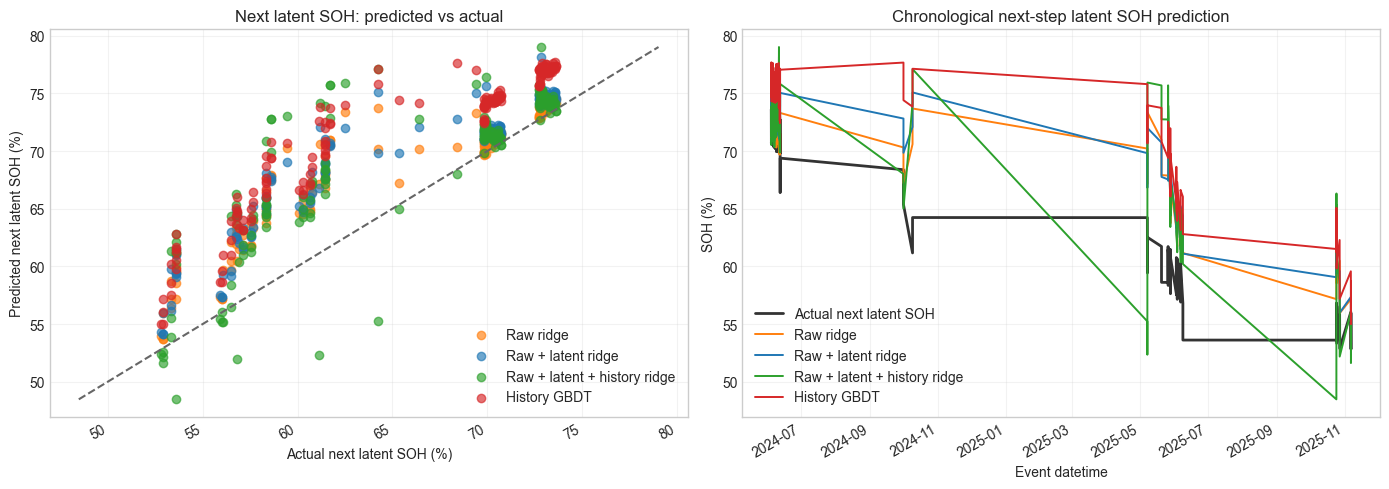

In [6]:
plot_df = test_df[
    [
        "battery_id",
        "event_datetime",
        "latent_soh_filter_pct",
        "next_latent_soh_causal_pct",
        "next_observed_soh_pct",
    ]
].copy()
plot_df["pred_next_level_raw_ridge"] = raw_pred_level
plot_df["pred_next_level_raw_latent_ridge"] = raw_latent_pred_level
plot_df["pred_next_level_history_ridge"] = history_pred_level
plot_df["pred_next_level_history_gbdt"] = history_gbdt_pred_level
plot_df["pred_next_delta_raw_ridge"] = raw_pred_delta
plot_df["pred_next_delta_raw_latent_ridge"] = raw_latent_pred_delta
plot_df["pred_next_delta_history_ridge"] = history_pred_delta
plot_df["pred_next_delta_history_gbdt"] = history_gbdt_pred_delta

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(plot_df["next_latent_soh_causal_pct"], plot_df["pred_next_level_raw_ridge"], alpha=0.65, label="Raw ridge", color="#ff7f0e")
axes[0].scatter(plot_df["next_latent_soh_causal_pct"], plot_df["pred_next_level_raw_latent_ridge"], alpha=0.65, label="Raw + latent ridge", color="#1f77b4")
axes[0].scatter(plot_df["next_latent_soh_causal_pct"], plot_df["pred_next_level_history_ridge"], alpha=0.65, label="Raw + latent + history ridge", color="#2ca02c")
axes[0].scatter(plot_df["next_latent_soh_causal_pct"], plot_df["pred_next_level_history_gbdt"], alpha=0.65, label="History GBDT", color="#d62728")
lo = min(
    plot_df["next_latent_soh_causal_pct"].min(),
    plot_df["pred_next_level_raw_ridge"].min(),
    plot_df["pred_next_level_raw_latent_ridge"].min(),
    plot_df["pred_next_level_history_ridge"].min(),
    plot_df["pred_next_level_history_gbdt"].min(),
)
hi = max(
    plot_df["next_latent_soh_causal_pct"].max(),
    plot_df["pred_next_level_raw_ridge"].max(),
    plot_df["pred_next_level_raw_latent_ridge"].max(),
    plot_df["pred_next_level_history_ridge"].max(),
    plot_df["pred_next_level_history_gbdt"].max(),
)
axes[0].plot([lo, hi], [lo, hi], linestyle="--", color="0.4")
axes[0].set_title("Next latent SOH: predicted vs actual")
axes[0].set_xlabel("Actual next latent SOH (%)")
axes[0].set_ylabel("Predicted next latent SOH (%)")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.25)

plot_df = plot_df.sort_values("event_datetime")
axes[1].plot(plot_df["event_datetime"], plot_df["next_latent_soh_causal_pct"], color="0.2", linewidth=2, label="Actual next latent SOH (causal)")
axes[1].plot(plot_df["event_datetime"], plot_df["pred_next_level_raw_ridge"], color="#ff7f0e", linewidth=1.4, label="Raw ridge")
axes[1].plot(plot_df["event_datetime"], plot_df["pred_next_level_raw_latent_ridge"], color="#1f77b4", linewidth=1.4, label="Raw + latent ridge")
axes[1].plot(plot_df["event_datetime"], plot_df["pred_next_level_history_ridge"], color="#2ca02c", linewidth=1.4, label="Raw + latent + history ridge")
axes[1].plot(plot_df["event_datetime"], plot_df["pred_next_level_history_gbdt"], color="#d62728", linewidth=1.4, label="History GBDT")
axes[1].set_title("Chronological next-step latent SOH prediction")
axes[1].set_xlabel("Event datetime")
axes[1].set_ylabel("SOH (%)")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()


## Which history features matter?

In [7]:
coef_df = pd.DataFrame(
    {
        "feature": X_train_history.columns,
        "coef": history_ridge.coef_,
        "abs_coef": np.abs(history_ridge.coef_),
    }
).sort_values("abs_coef", ascending=False)
display(coef_df.head(30).round(4))


,feature,coef,abs_coef
0,observed_soh_pct,1.2100,1.2100
15,prev_observed_soh_pct,1.1865,1.1865
25,rolling_latent_filter_std_3,-0.9341,0.9341
30,rolling_temp_mean_5,-0.7948,0.7948
29,rolling_current_abs_max_5,-0.7667,0.7667
26,rolling_latent_filter_delta_mean_5,-0.7078,0.7078
28,rolling_current_abs_mean_5,0.6902,0.6902
12,latent_soh_filterpy_filter_pct,-0.6706,0.6706
11,latent_soh_filter_pct,-0.6706,0.6706
13,_filterpy_pred_state_pct,-0.6684,0.6684


## Save outputs

In [8]:
predictive_df.to_csv(RESULT_DIR / "latent_history_predictive_dataset.csv", index=False)
plot_df.to_csv(RESULT_DIR / "latent_history_test_predictions.csv", index=False)
metrics.to_csv(RESULT_DIR / "latent_history_prediction_metrics.csv", index=False)
coef_df.to_csv(RESULT_DIR / "latent_history_ridge_coefficients.csv", index=False)

print("Saved outputs to", RESULT_DIR)


Saved outputs to /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/output/latent_history_plane_166


## Interpretation

In [9]:
display(metrics.round(4))
best_row = metrics.sort_values("level_mae").iloc[0]
print(f"Best model by next-level MAE: {best_row['model']}")
print("- `ridge_raw_only` tests whether plain event descriptors can forecast next denoised SOH.")
print("- `ridge_raw_plus_latent` tests whether current latent filter state adds signal beyond raw event features.")
print("- `ridge_raw_plus_latent_plus_history` tests whether transition context makes the latent representation useful for forecasting.")
print("- If the history-enhanced ridge wins, the likely gain is coming from causal state-transition structure rather than from smoother leakage.")


,model,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,3.4447,4.4370,0.6041,3.4447,4.4370,-1.5171
1,ridge_raw_only,3.0090,4.1957,0.6460,3.0090,4.1957,-1.2508
2,ridge_raw_plus_latent,3.6286,4.5740,0.5793,3.6286,4.5740,-1.6750
3,ridge_raw_plus_latent_plus_history,3.6345,5.1837,0.4597,3.6345,5.1837,-2.4356
4,gbdt_raw_plus_latent_plus_history,5.7361,6.3082,0.1998,5.7361,6.3082,-4.0879


Best model by next-level MAE: ridge_raw_only
- `ridge_raw_only` tests whether plain event descriptors can forecast next denoised SOH.
- `ridge_raw_plus_latent` tests whether current latent filter state adds signal beyond raw event features.
- `ridge_raw_plus_latent_plus_history` tests whether transition context makes the latent representation useful for forecasting.
- If the history-enhanced ridge wins, the likely gain is coming from causal state-transition structure rather than from smoother leakage.
